In [1]:
import os
import json
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # adjust slug if needed

TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"

VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"

TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"   # only annotations available for test

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
TARGET_RATIO = 0.6

random.seed(42)

# Count category frequencies
category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}


from concurrent.futures import ThreadPoolExecutor
print("Scanning dataset annotations...")

def process_annotation(args):

    IMAGE_DIR, ANN_DIR, ann_file = args

    if not ann_file.endswith(".json"):
        return None

    ann_path = os.path.join(ANN_DIR, ann_file)

    try:
        with open(ann_path) as f:
            data = json.load(f)
    except:
        return None

    if not isinstance(data, dict):
        return None

    cats = set()
    local_names = {}

    for key, val in data.items():

        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:

            cat = val["category_id"]
            cats.add(cat)

            if "category_name" in val:
                local_names[cat] = val["category_name"]

    if len(cats) == 0:
        return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))

    if not os.path.exists(image_path):
        return None

    return image_path, cats, local_names

tasks = []

for IMAGE_DIR, ANN_DIR in DATA_SPLITS:
    for ann_file in os.listdir(ANN_DIR):
        tasks.append((IMAGE_DIR, ANN_DIR, ann_file))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:

    if r is None:
        continue

    image_path, cats, local_names = r

    image_to_categories[image_path] = list(cats)

    for c in cats:
        category_counter[c] += 1

    category_id_to_name.update(local_names)


print("\nCategory frequencies:")
print(category_counter)

# Select top 5 categories
top5 = [c for c, _ in category_counter.most_common(5)]

print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

# Filter images containing top-5 classes
filtered_images = []

for img, cats in image_to_categories.items():

    filtered = [c for c in cats if c in top5]

    if len(filtered) > 0:
        filtered_images.append((img, filtered))


print("\nImages after filtering:", len(filtered_images))

# Create multi-label vectors
dataset = []

for img, cats in filtered_images:

    label_vector = [0] * NUM_CLASSES

    for c in cats:
        label_vector[label_map[c]] = 1

    dataset.append({
        "image": img,
        "labels": label_vector
    })


print("Dataset entries created:", len(dataset))

# Balanced subset sampling
target_size = int(len(dataset) * TARGET_RATIO)

print("\nCreating balanced subset:", target_size)

class_buckets = defaultdict(list)

for sample in dataset:

    for idx, val in enumerate(sample["labels"]):

        if val == 1:
            class_buckets[idx].append(sample)


subset = []
seen = set()

target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):

    candidates = class_buckets[cls]
    random.shuffle(candidates)

    selected = 0

    for sample in candidates:

        if sample["image"] in seen:
            continue

        subset.append(sample)
        seen.add(sample["image"])
        selected += 1

        if selected >= target_per_class:
            break

print("Subset size:", len(subset))

# Train / Validation / Test split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Save splits
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:

    imgs, lbls = splits[split]

    data = []

    for img, lbl in zip(imgs, lbls):

        data.append({
            "image": os.path.relpath(img, start=BASE),
            "labels": lbl
        })

    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{split} file saved → {out_path}")


print("\nPreprocessing completed successfully.")

# Save label_map so preprocessing_detection.py can read the exact same top-5
# Create required format: class_name -> index
# Required class order from assignment
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

print("\nFinal Label Mapping (class_name -> index):")
for name, idx in label_map_json.items():
    print(f"{name} : {idx}")

# Save label_map.json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("\nlabel_map.json saved in required format.")

Scanning dataset annotations...

Category frequencies:
Counter({1: 82957, 8: 64463, 2: 41667, 7: 40465, 9: 37124, 12: 21086, 10: 20104, 5: 18072, 4: 15380, 11: 9263, 13: 7592, 6: 2281, 3: 681})

Top 5 categories: [1, 8, 2, 7, 9]

Images after filtering: 167915
Dataset entries created: 167915

Creating balanced subset: 100749
Subset size: 100745

Split sizes:
Train: 70521
Validation: 15112
Test: 15112
train file saved → /kaggle/working/processed_dataset/train.json
val file saved → /kaggle/working/processed_dataset/val.json
test file saved → /kaggle/working/processed_dataset/test.json

Preprocessing completed successfully.

Final Label Mapping (class_name -> index):
short sleeve top : 0
trousers : 1
shorts : 2
long sleeve top : 3
skirt : 4

label_map.json saved in required format.


In [3]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # Adjust slug if needed
TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"
VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"
TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(42)

category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}

print("Scanning dataset annotations...")

def process_annotation(args):
    IMAGE_DIR, ANN_DIR, ann_file = args
    if not ann_file.endswith(".json"): return None
    ann_path = os.path.join(ANN_DIR, ann_file)
    try:
        with open(ann_path) as f: data = json.load(f)
    except: return None
    if not isinstance(data, dict): return None

    cats = set()
    local_names = {}
    for key, val in data.items():
        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:
            cat = val["category_id"]
            cats.add(cat)
            if "category_name" in val:
                local_names[cat] = val["category_name"]
    if len(cats) == 0: return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))
    if not os.path.exists(image_path): return None

    return image_path, cats, local_names

tasks = [(I, A, f) for I, A in DATA_SPLITS for f in os.listdir(A)]

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:
    if r is None: continue
    image_path, cats, local_names = r
    image_to_categories[image_path] = list(cats)
    for c in cats: category_counter[c] += 1
    category_id_to_name.update(local_names)

top5 = [c for c, _ in category_counter.most_common(5)]
print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

filtered_images = []
for img, cats in image_to_categories.items():
    filtered = [c for c in cats if c in top5]
    if len(filtered) > 0:
        filtered_images.append((img, filtered))

dataset = []
for img, cats in filtered_images:
    label_vector = [0] * NUM_CLASSES
    for c in cats: label_vector[label_map[c]] = 1
    dataset.append({"image": img, "labels": label_vector})

# ========================================================
# STRICT 15,000 IMAGE LIMIT APPLIED HERE
# ========================================================
target_size = 15000 
print(f"\nCreating balanced subset of EXACTLY {target_size} images...")

class_buckets = defaultdict(list)
for sample in dataset:
    for idx, val in enumerate(sample["labels"]):
        if val == 1: class_buckets[idx].append(sample)

subset = []
seen = set()
target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):
    candidates = class_buckets[cls]
    random.shuffle(candidates)
    selected = 0
    for sample in candidates:
        if sample["image"] in seen: continue
        subset.append(sample)
        seen.add(sample["image"])
        selected += 1
        if selected >= target_per_class: break

print("Final Subset size:", len(subset))

# 70/15/15 Split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(images, labels, test_size=0.30, random_state=42)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(temp_imgs, temp_labels, test_size=0.5, random_state=42)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:
    imgs, lbls = splits[split]
    data = [{"image": os.path.relpath(img, start=BASE), "labels": lbl} for img, lbl in zip(imgs, lbls)]
    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")
    with open(out_path, "w") as f: json.dump(data, f, indent=2)

# Save standard label map
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("Base preprocessing complete. Master splits locked to 15k.")

Scanning dataset annotations...

Top 5 categories: [1, 8, 2, 7, 9]

Creating balanced subset of EXACTLY 15000 images...
Final Subset size: 15000
Base preprocessing complete. Master splits locked to 15k.


In [4]:
import os
import json
import shutil
import numpy as np
from PIL import Image, ImageDraw

CLASSIFICATION_OUTPUT_DIR = "/kaggle/working/processed_dataset"
OUTPUT_DIR = "/kaggle/working/processed_dataset"
BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"

ALL_ANN_DIRS = [f"{BASE}/train/annos", f"{BASE}/validation/annos", f"{BASE}/json_for_validation"]
ALL_IMAGE_DIRS = [f"{BASE}/train/image", f"{BASE}/validation/image", f"{BASE}/test/test"]

CATEGORY_NAMES = {
    1: "short_sleeve_top", 2: "long_sleeve_top", 3: "short_sleeve_outwear",
    4: "long_sleeve_outwear", 5: "vest", 6: "sling", 7: "shorts",
    8: "trousers", 9: "skirt", 10: "short_sleeve_dress",
    11: "long_sleeve_dress", 12: "vest_dress", 13: "sling_dress",
}

with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, "label_map.json")) as f:
    class_name_to_idx = json.load(f)

label_map = {}
top5 = []
for orig_id, name in CATEGORY_NAMES.items():
    readable_name = name.replace("_", " ")
    if readable_name in class_name_to_idx:
        label_map[orig_id] = class_name_to_idx[readable_name]
        top5.append(orig_id)

NUM_CLASSES = len(label_map)

split_map = {}
for split_name in ["train", "val", "test"]:
    with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, f"{split_name}.json")) as f:
        records = json.load(f)
    split_map[split_name] = [r["image"] for r in records]

stem_to_ann, stem_to_img = {}, {}
for ann_dir in ALL_ANN_DIRS:
    if not os.path.isdir(ann_dir): continue
    for ann_file in os.listdir(ann_dir):
        if ann_file.endswith(".json"): stem_to_ann[os.path.splitext(ann_file)[0]] = os.path.join(ann_dir, ann_file)

for img_dir in ALL_IMAGE_DIRS:
    if not os.path.isdir(img_dir): continue
    for img_file in os.listdir(img_dir):
        stem_to_img[os.path.splitext(img_file)[0]] = os.path.join(img_dir, img_file)

def stem_from_path(path): return os.path.splitext(os.path.basename(path))[0]
def get_image_size(img_path):
    try:
        with Image.open(img_path) as im: return im.width, im.height
    except: return 0, 0
def polygon_area(poly):
    n = len(poly) // 2
    if n < 3: return 0.0
    xs, ys = [poly[2 * i] for i in range(n)], [poly[2 * i + 1] for i in range(n)]
    area = sum(xs[i] * ys[(i + 1) % n] - xs[(i + 1) % n] * ys[i] for i in range(n))
    return abs(area) / 2.0

def parse_annotations(ann_path):
    with open(ann_path) as f: data = json.load(f)
    instances = []
    for key, item in data.items():
        if not key.startswith("item"): continue
        orig_cat = item.get("category_id")
        if orig_cat not in label_map or item.get("bounding_box") is None: continue
        instances.append({
            "category_id": label_map[orig_cat], "original_category_id": orig_cat,
            "bbox": item["bounding_box"], "segmentation": item.get("segmentation") or [],
        })
    return instances

def resolve(stored_path):
    stem = stem_from_path(stored_path)
    img_path = stored_path if os.path.exists(stored_path) else stem_to_img.get(stem)
    if stem_to_ann.get(stem) is None or img_path is None: return None
    return stem, stem_to_ann[stem], img_path

def save_detection_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_detection.json")
    records = []
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if resolved and (instances := parse_annotations(resolved[1])):
            records.append({"image": resolved[2], "annotations": instances})
    with open(out_path, "w") as f: json.dump(records, f, indent=2)

def save_coco_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_coco.json")
    categories = sorted([{"id": label_map[orig] + 1, "name": CATEGORY_NAMES.get(orig, str(orig))} for orig in top5], key=lambda x: x["id"])
    images_out, anns_out = [], []
    image_id, ann_id = 1, 1
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if not resolved or not (instances := parse_annotations(resolved[1])): continue
        w, h = get_image_size(resolved[2])
        images_out.append({"id": image_id, "file_name": resolved[2], "width": w, "height": h})
        for inst in instances:
            x1, y1, x2, y2 = inst["bbox"]
            area = sum(polygon_area(p) for p in inst["segmentation"]) or float((x2 - x1) * (y2 - y1))
            anns_out.append({"id": ann_id, "image_id": image_id, "category_id": inst["category_id"] + 1,
                             "bbox": [x1, y1, x2 - x1, y2 - y1], "area": area, "segmentation": inst["segmentation"], "iscrowd": 0})
            ann_id += 1
        image_id += 1
    with open(out_path, "w") as f: json.dump({"images": images_out, "annotations": anns_out, "categories": categories}, f, indent=2)

def save_yolo(split_map_local):
    yolo_root = os.path.join(OUTPUT_DIR, "yolo_dataset")
    for split_name, image_list in split_map_local.items():
        img_out, lbl_out = os.path.join(yolo_root, "images", split_name), os.path.join(yolo_root, "labels", split_name)
        os.makedirs(img_out, exist_ok=True); os.makedirs(lbl_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            dst_img = os.path.join(img_out, os.path.basename(resolved[2]))
            if not os.path.exists(dst_img): shutil.copy2(resolved[2], dst_img)
            lines = []
            for inst in instances:
                cls, (x1, y1, x2, y2) = inst["category_id"], inst["bbox"]
                lines.append(f"{cls} {((x1 + x2) / 2) / w:.6f} {((y1 + y2) / 2) / h:.6f} {(x2 - x1) / w:.6f} {(y2 - y1) / h:.6f}")
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: lines.append(f"{cls} " + " ".join([f"{poly[k]/w:.6f} {poly[k+1]/h:.6f}" for k in range(0, len(poly), 2)]))
            with open(os.path.join(lbl_out, resolved[0] + ".txt"), "w") as f: f.write("\n".join(lines))
    
    class_names = [None] * NUM_CLASSES
    for orig_id, idx in label_map.items(): class_names[idx] = CATEGORY_NAMES.get(orig_id, str(orig_id)).replace("_", " ")
    with open(os.path.join(yolo_root, "dataset.yaml"), "w") as f:
        f.write("\n".join([f"path: {os.path.abspath(yolo_root)}", "train: images/train", "val: images/val", "test: images/test", "", f"nc: {NUM_CLASSES}", f"names: {class_names}"]))

def save_unet_masks(split_map_local):
    mask_root = os.path.join(OUTPUT_DIR, "unet_masks")
    for split_name, image_list in split_map_local.items():
        mask_out = os.path.join(mask_root, split_name)
        os.makedirs(mask_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            pil_mask, draw = Image.fromarray(np.zeros((h, w), dtype=np.uint8)), ImageDraw.Draw(Image.fromarray(np.zeros((h, w), dtype=np.uint8)))
            for inst in instances:
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: draw.polygon([(poly[k], poly[k+1]) for k in range(0, len(poly), 2)], fill=inst["category_id"] + 1)
            draw._image.save(os.path.join(mask_out, resolved[0] + ".png"))

print("\n--- Generating Generic Detection JSONs ---")
for split_name, image_list in split_map.items(): save_detection_json(split_name, image_list)
print("\n--- Generating COCO JSONs (Mask R-CNN) ---")
for split_name, image_list in split_map.items(): save_coco_json(split_name, image_list)
print("\n--- Generating YOLO Dataset ---")
save_yolo(split_map)
print("\n--- Generating U-Net Semantic Masks ---")
save_unet_masks(split_map)

print("\n15k Formatting completely finished. You are ready to train.")


--- Generating Generic Detection JSONs ---

--- Generating COCO JSONs (Mask R-CNN) ---

--- Generating YOLO Dataset ---

--- Generating U-Net Semantic Masks ---

15k Formatting completely finished. You are ready to train.


In [5]:
!pip install pycocotools -q

import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import json
import os
from PIL import Image
import cv2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COCO_TRAIN = "/kaggle/working/processed_dataset/train_coco.json"
COCO_VAL   = "/kaggle/working/processed_dataset/val_coco.json"

NUM_CLASSES = 6  # 5 + background

print("Setup complete")

Setup complete


In [6]:
class FashionDataset(Dataset):
    def __init__(self, coco_path):
        with open(coco_path) as f:
            self.coco = json.load(f)

        # -------------------------------
        # STEP 1 — Load full data
        # -------------------------------
        all_images = self.coco["images"]
        all_anns   = self.coco["annotations"]

        # Map image_id → annotations
        img_to_anns = {}
        for ann in all_anns:
            img_to_anns.setdefault(ann["image_id"], []).append(ann)

        # -------------------------------
        # STEP 2 — Balanced sampling
        # -------------------------------
        MAX_IMAGES = 15000
        per_class = MAX_IMAGES // 5

        class_buckets = {i: [] for i in range(1, 6)}

        for img in all_images:
            anns = img_to_anns.get(img["id"], [])
            cats = set(a["category_id"] for a in anns)

            for c in cats:
                if c in class_buckets:
                    class_buckets[c].append(img)

        selected_ids = set()

        for c in class_buckets:
            np.random.shuffle(class_buckets[c])
            count = 0

            for img in class_buckets[c]:
                if img["id"] in selected_ids:
                    continue

                selected_ids.add(img["id"])
                count += 1

                if count >= per_class:
                    break

        # -------------------------------
        # STEP 3 — Filter images
        # -------------------------------
        self.images = [img for img in all_images if img["id"] in selected_ids]

        # -------------------------------
        # STEP 4 — Filter annotations
        # -------------------------------
        self.anns = [
            ann for ann in all_anns
            if ann["image_id"] in selected_ids
        ]

        # -------------------------------
        # STEP 5 — Rebuild mapping
        # -------------------------------
        self.img_to_anns = {}
        for ann in self.anns:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        print(f"Loaded {len(self.images)} images (balanced subset)")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]

        img = Image.open(img_info["file_name"]).convert("RGB")
        img = torchvision.transforms.functional.to_tensor(img)

        anns = self.img_to_anns.get(img_info["id"], [])

        boxes, labels, masks = [], [], []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

            mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

            for seg in ann["segmentation"]:
                poly = np.array(seg).reshape(-1, 2)
                cv2.fillPoly(mask, [poly.astype(np.int32)], 1)

            masks.append(mask)

        # Handle edge case (no objects)
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, img_info["height"], img_info["width"]), dtype=torch.uint8)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([img_info["id"]])
        }

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_loader = DataLoader(
    FashionDataset(COCO_TRAIN),
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    FashionDataset(COCO_VAL),
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

print("Dataset ready")

Loaded 9895 images (balanced subset)
Loaded 2162 images (balanced subset)
Dataset ready


In [7]:
model = maskrcnn_resnet50_fpn(weights=None, num_classes=NUM_CLASSES)
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = [i.to(DEVICE) for i in imgs]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss = sum(model(imgs, targets).values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[Scratch] Epoch {epoch+1}: Loss={total_loss:.3f}")

torch.save(model.state_dict(), "/kaggle/working/maskrcnn_scratch.pth")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s] 


[Scratch] Epoch 1: Loss=1420.676
[Scratch] Epoch 2: Loss=1024.652
[Scratch] Epoch 3: Loss=911.713
[Scratch] Epoch 4: Loss=842.065
[Scratch] Epoch 5: Loss=770.206
[Scratch] Epoch 6: Loss=712.067
[Scratch] Epoch 7: Loss=665.412
[Scratch] Epoch 8: Loss=620.515
[Scratch] Epoch 9: Loss=582.116
[Scratch] Epoch 10: Loss=550.598


In [8]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

model = maskrcnn_resnet50_fpn(weights="DEFAULT")

# -----------------------------
# Replace heads (VERY IMPORTANT)
# -----------------------------
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features, NUM_CLASSES
)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    256,
    NUM_CLASSES
)

model.to(DEVICE)

# -----------------------------
# Freeze backbone (REQUIRED)
# -----------------------------
for param in model.backbone.parameters():
    param.requires_grad = False

# -----------------------------
# Train only heads
# -----------------------------
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4
)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = [i.to(DEVICE) for i in imgs]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss = sum(model(imgs, targets).values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[Transfer] Epoch {epoch+1}: Loss={total_loss:.3f}")

torch.save(model.state_dict(), "/kaggle/working/maskrcnn_transfer.pth")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 190MB/s]  


[Transfer] Epoch 1: Loss=1314.488
[Transfer] Epoch 2: Loss=1116.887
[Transfer] Epoch 3: Loss=1040.469
[Transfer] Epoch 4: Loss=983.344
[Transfer] Epoch 5: Loss=946.358
[Transfer] Epoch 6: Loss=909.569
[Transfer] Epoch 7: Loss=875.034
[Transfer] Epoch 8: Loss=841.406
[Transfer] Epoch 9: Loss=810.511
[Transfer] Epoch 10: Loss=794.468


In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# -----------------------------
# IoU function
# -----------------------------
def iou(box1, box2):
    x1,y1,x2,y2 = box1
    x1g,y1g,x2g,y2g = box2

    xa, ya = max(x1,x1g), max(y1,y1g)
    xb, yb = min(x2,x2g), min(y2,y2g)

    inter = max(0, xb-xa)*max(0, yb-ya)
    union = (x2-x1)*(y2-y1)+(x2g-x1g)*(y2g-y1g)-inter

    return inter/union if union else 0


# -----------------------------
# FULL EVALUATION FUNCTION
# -----------------------------
def evaluate(model, name):

    print(f"\n==============================")
    print(f"     {name} MODEL RESULTS")
    print(f"==============================")

    model.eval()

    tp, fp, fn = [0]*5, [0]*5, [0]*5
    scores_pc = [[] for _ in range(5)]
    labels_pc = [[] for _ in range(5)]

    ious = [[] for _ in range(5)]
    dices = [[] for _ in range(5)]

    # -----------------------------
    # MAIN LOOP
    # -----------------------------
    with torch.no_grad():
        for imgs, targets in val_loader:

            imgs = [i.to(DEVICE) for i in imgs]
            outputs = model(imgs)

            for pred, gt in zip(outputs, targets):

                gt_boxes = gt["boxes"].numpy()
                gt_labels = gt["labels"].numpy()

                matched = set()

                # -----------------------------
                # DETECTION MATCHING
                # -----------------------------
                for pb, pl, sc in zip(
                    pred["boxes"].cpu().numpy(),
                    pred["labels"].cpu().numpy(),
                    pred["scores"].cpu().numpy()
                ):
                    best_iou, best_idx = 0, -1

                    for i,(gb,gl) in enumerate(zip(gt_boxes, gt_labels)):
                        val = iou(pb, gb)
                        if val > best_iou:
                            best_iou, best_idx = val, i

                    if best_iou >= 0.5:
                        if pl == gt_labels[best_idx]:
                            tp[pl-1]+=1
                            matched.add(best_idx)
                            label=1
                        else:
                            fp[pl-1]+=1
                            label=0
                    else:
                        fp[pl-1]+=1
                        label=0

                    scores_pc[pl-1].append(sc)
                    labels_pc[pl-1].append(label)

                for i,(gb,gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if i not in matched:
                        fn[gl-1]+=1

                # -----------------------------
                # SEGMENTATION METRICS
                # -----------------------------
                if "masks" in pred:
                    pred_masks = pred["masks"].cpu().numpy()
                    gt_masks = gt["masks"].numpy()

                    for i in range(min(len(pred_masks), len(gt_masks))):
                        pm = pred_masks[i][0] > 0.5
                        gm = gt_masks[i]

                        inter = (pm & gm).sum()
                        union = (pm | gm).sum()

                        if union == 0:
                            continue

                        cls = gt_labels[i] - 1

                        ious[cls].append(inter / union)
                        dices[cls].append(2 * inter / (pm.sum() + gm.sum() + 1e-6))

    # -----------------------------
    # DETECTION METRICS
    # -----------------------------
    print("\n🔹 Detection Metrics:")

    f1s = []
    for i in range(5):
        p = tp[i]/(tp[i]+fp[i]+1e-6)
        r = tp[i]/(tp[i]+fn[i]+1e-6)
        f = 2*p*r/(p+r+1e-6)
        f1s.append(f)

        print(f"Class {i}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

    macro_f1 = np.mean(f1s)
    print(f"\nMacro F1: {macro_f1:.3f}")

    total_tp = sum(tp)
    total_fp = sum(fp)
    total_fn = sum(fn)

    micro_f1 = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-6)
    print(f"Micro F1: {micro_f1:.3f}")

    # -----------------------------
    # ROC CURVES
    # -----------------------------
    print("\n🔹 ROC Curves:")

    plt.figure(figsize=(15,4))

    for i in range(5):
        if len(set(labels_pc[i])) < 2:
            continue

        fpr,tpr,_ = roc_curve(labels_pc[i], scores_pc[i])
        roc_auc = auc(fpr,tpr)

        plt.subplot(1,5,i+1)
        plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.title(f"Class {i}")
        plt.legend()

    plt.suptitle(f"ROC Curves - {name}")
    plt.show()

    # -----------------------------
    # SEGMENTATION METRICS
    # -----------------------------
    print("\n🔹 Segmentation Metrics:")

    for i in range(5):
        if ious[i]:
            print(f"Class {i}: IoU={np.mean(ious[i]):.3f}, Dice={np.mean(dices[i]):.3f}")

    miou = np.mean([np.mean(x) for x in ious if x])
    dice = np.mean([np.mean(x) for x in dices if x])

    print(f"\nmIoU: {miou:.3f}")
    print(f"Dice: {dice:.3f}")

    # -----------------------------
    # COCO mAP
    # -----------------------------
    print("\n🔹 COCO mAP:")

    coco_gt = COCO(COCO_VAL)
    results = []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [i.to(DEVICE) for i in imgs]
            outputs = model(imgs)

            for pred, gt in zip(outputs, targets):
                image_id = int(gt["image_id"].item())

                for box, score, label in zip(
                    pred["boxes"].cpu().numpy(),
                    pred["scores"].cpu().numpy(),
                    pred["labels"].cpu().numpy()
                ):
                    x1,y1,x2,y2 = box
                    results.append({
                        "image_id": image_id,
                        "category_id": int(label),
                        "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                        "score": float(score)
                    })

    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()


     SCRATCH MODEL RESULTS

🔹 Detection Metrics:
Class 0: Precision=0.361, Recall=0.991, F1=0.529
Class 1: Precision=0.349, Recall=0.979, F1=0.515
Class 2: Precision=0.340, Recall=0.973, F1=0.504
Class 3: Precision=0.318, Recall=0.980, F1=0.481
Class 4: Precision=0.324, Recall=0.972, F1=0.486

Macro F1: 0.503
Micro F1: 0.505

🔹 ROC Curves:


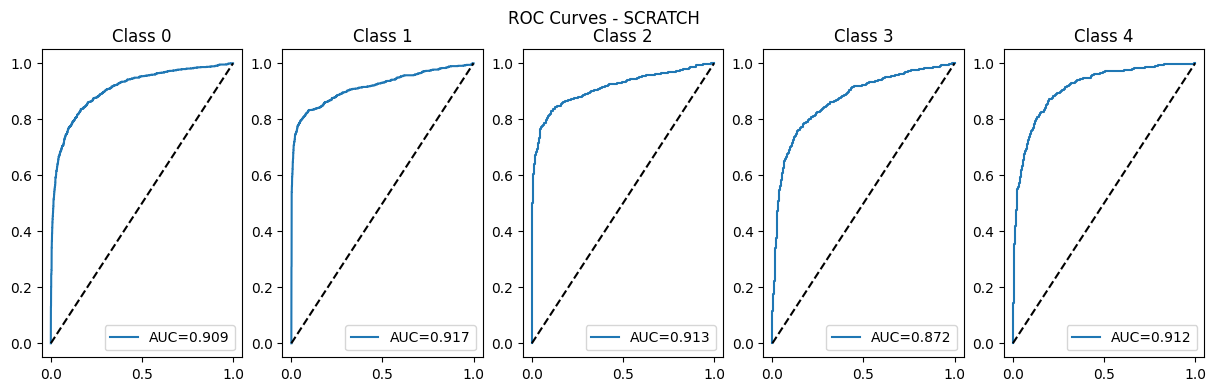


🔹 Segmentation Metrics:
Class 0: IoU=0.401, Dice=0.443
Class 1: IoU=0.480, Dice=0.537
Class 2: IoU=0.492, Dice=0.549
Class 3: IoU=0.513, Dice=0.566
Class 4: IoU=0.419, Dice=0.463

mIoU: 0.461
Dice: 0.512

🔹 COCO mAP:
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.09s).
Accumulating evaluation results...
DONE (t=0.60s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.627
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.873
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.742
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.400
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.466
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.632
 Averag

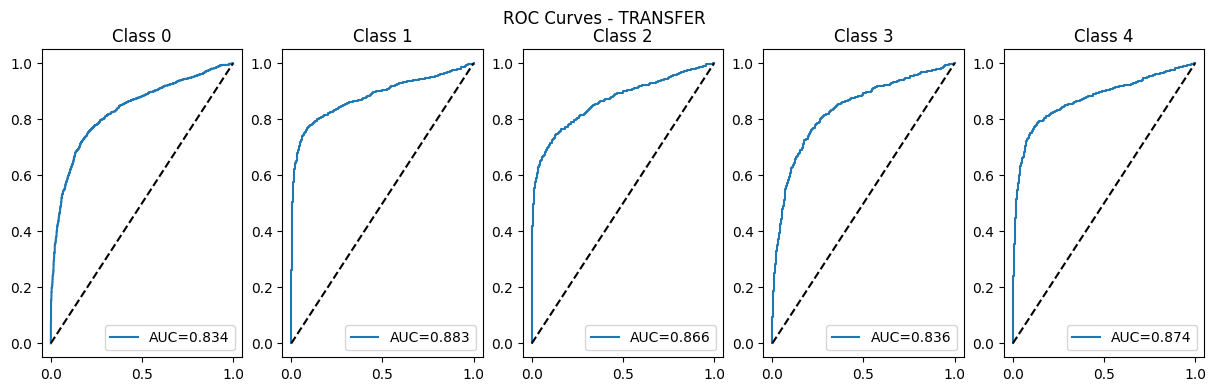


🔹 Segmentation Metrics:
Class 0: IoU=0.488, Dice=0.539
Class 1: IoU=0.486, Dice=0.550
Class 2: IoU=0.506, Dice=0.569
Class 3: IoU=0.497, Dice=0.559
Class 4: IoU=0.608, Dice=0.666

mIoU: 0.517
Dice: 0.577

🔹 COCO mAP:
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.36s).
Accumulating evaluation results...
DONE (t=0.83s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.524
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.817
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.611
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.300
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.428
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.527
 Averag

In [10]:
# Scratch
model_s = maskrcnn_resnet50_fpn(weights=None, num_classes=NUM_CLASSES)
model_s.load_state_dict(torch.load("/kaggle/working/maskrcnn_scratch.pth"))
model_s.to(DEVICE)

evaluate(model_s, "SCRATCH")


# Transfer
model_t = maskrcnn_resnet50_fpn(weights=None, num_classes=NUM_CLASSES)
model_t.load_state_dict(torch.load("/kaggle/working/maskrcnn_transfer.pth"))
model_t.to(DEVICE)

evaluate(model_t, "TRANSFER")